In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt



In [2]:
import tensorflow as tf 

In [3]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, TimeDistributed
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from cmath import sqrt

In [4]:
np.random.seed(7)
tf.random.set_seed(7)

In [6]:
#CARGAR LOS DATOS
data_train = pd.read_csv('train.csv', parse_dates=['date'])
data_test = pd.read_csv('test.csv', parse_dates=['date'])

#FILTRAR UNA SERIE
train= data_train.query("store==1 & item==1").copy()
train= train.sort_values('date')
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [7]:
print(len(train))

1826


In [8]:
def make_supervised_windows(series: np.ndarray, window: int, lag: int):
    X, y = [], []
    for i in range(window, len(series) - lag):
        X.append(series[i-window: i+1])
        y.append(series[i + lag])
    return np.array(X), np.array(y)

window = 29
lag = 1

X, y= make_supervised_windows(train['sales'].values, window, lag)
print("X", X.shape, "y", y.shape)

X (1796, 30) y (1796,)


In [9]:
# DIVISION TEMPORAL Y ESCALADO 
cut= int(len(X)* 0.8)
X_train, X_test= X[:cut], X[cut:]
y_train, y_test= y[:cut], y[cut:]

scaler_x= StandardScaler().fit(X_train)
scaler_y= StandardScaler().fit(y_train.reshape(-1, 1))

X_train_s = scaler_x.transform(X_train)
X_test_s = scaler_x.transform(X_test)
y_train_s = scaler_y.transform(y_train.reshape(-1, 1)).ravel()
y_test_s = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print("X_train_s", X_train_s.shape, "y_train_s", y_train_s.shape)

X_train_3d = X_train_s.reshape((len(X_train_s), window+1, 1))
X_test_3d = X_test_s.reshape((len(X_test_s), window+1, 1))

print("Train 3d:", X_train_3d.shape, "Test 3d:", X_test_3d.shape)

X_train_s (1436, 30) y_train_s (1436,)
Train 3d: (1436, 30, 1) Test 3d: (360, 30, 1)


In [22]:
## CNN 1D

model_cnn = Sequential([
    Conv1D(filters=32, kernel_size=3, activation="relu", input_shape=(window+1, 1)), 
    MaxPooling1D(pool_size=2), 
    Flatten(), 
    Dense(32, activation="relu"), 
    Dense(1)
])

model_cnn.compile(optimizer="adam", loss="mse")
model_cnn.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 28, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │        14,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,529 (56.75 KB)

 Trainable params: 14,529 (56.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history_cnn = model_cnn.fit(X_train_3d, y_train_s, epochs=50, batch_size=32, verbose=0)

2025-11-03 21:15:29.046988: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


In [14]:
# Prediction


pred_cnn_s = model_cnn.predict(X_test_3d)
pred_cnn = scaler_y.inverse_transform(pred_cnn_s.reshape(-1, 1)).ravel()
print("RMSE: ", sqrt(mean_squared_error(y_test, pred_cnn)))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
RMSE:  (5.751381417895298+0j)


In [15]:
# LSTM
model_lstm = Sequential([
    LSTM(32, activation="tanh", input_shape=(window+1, 1)), 
    Dense(1)
])
model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_lstm = model_lstm.fit(X_train_3d, y_train_s, epochs=50, batch_size= 32, verbose =1)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.7588
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.6681
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6659
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6643
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6629
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6616
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.6604
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.6592
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.6580
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.6566
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.6551
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.6533
Epoch 13/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6512
Epoch 14/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.6488
Epoch 15/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6459
Epoc

In [17]:
pred_lstm_s = model_lstm.predict(X_test_3d).ravel()
pred_lstm = scaler_y.inverse_transform(pred_lstm_s.reshape(-1, 1)).ravel()
print("RMSE: ", sqrt(mean_squared_error(y_test, pred_lstm)))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
RMSE:  (5.200832835774377+0j)


In [23]:
# CNN + LSTM
subseq = 5
assert(window + 1) % subseq == 0, "window must be divisible by subseq"
step_per_subseq = (window+ 1) // subseq

Xtr4 = X_train_3d.reshape((len(X_train_3d), subseq, step_per_subseq, 1))
Xva4 = X_test_3d.reshape((len(X_test_3d), subseq, step_per_subseq, 1))

model_cnn_lstm = Sequential([
    TimeDistributed(Conv1D(filters=32, kernel_size=3, activation="relu"), 
                    input_shape=(subseq, step_per_subseq, 1)),
    TimeDistributed(MaxPooling1D(2)),
    TimeDistributed(Flatten()),  
    LSTM(32, activation="tanh"),
    Dense(1)
])

model_cnn_lstm.compile(optimizer="adam", loss="mse")
model_cnn_lstm.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_6              │ (None, 5, 4, 32)       │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 5, 2, 32)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 5, 64)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,577 (49.13 KB)

 Trainable params: 12,577 (49.13 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history_cnn_lstm = model_cnn_lstm.fit(Xtr4, 
                                      y_train_s, 
                                      epochs=50, 
                                      batch_size=32, 
                                      verbose=1)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.7197
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.6493
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.6342
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.6229
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.6137
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.6058
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.5988
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5926
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5870
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5819
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5772
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5728
Epoch 13/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.5686
Epoch 14/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.5647
Epoch 15/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.5610
Epoc

In [25]:
pred_cnn_lstm_s = model_cnn_lstm.predict(Xva4).ravel()
pred_cnn_lstm = scaler_y.inverse_transform(pred_cnn_lstm_s.reshape(-1, 1)).ravel()
print("RMSE: ", sqrt(mean_squared_error(y_test, pred_cnn_lstm)))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
RMSE:  (5.240124815407996+0j)


In [26]:
# Plotting results
rmse_cnn = sqrt(mean_squared_error(y_test, pred_cnn))
rmse_lstm = sqrt(mean_squared_error(y_test, pred_lstm))
rmse_cnn_lstm = sqrt(mean_squared_error(y_test, pred_cnn_lstm))

print("Summary RMSE")
print("CNN", rmse_cnn)
print("LSTM: ", rmse_lstm)
print("CNN + LSTM", rmse_cnn_lstm)

Summary RMSE
CNN (5.751381417895298+0j)
LSTM:  (5.200832835774377+0j)
CNN + LSTM (5.240124815407996+0j)


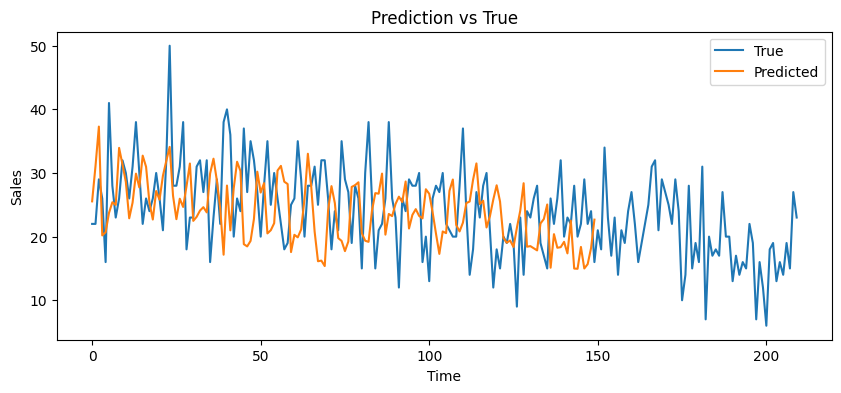

In [27]:
y_true = y_test
y_pred = pred_cnn

k  = 150 if len(y_true) > 150 else len(y_true)

plt.figure(figsize=(10, 4))
plt.plot(y_true[k:], label="True")
plt.plot(y_pred[-k:], label="Predicted")
plt.title("Prediction vs True")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()